Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      12,845,568 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 53,259,089 (203.17 MB)

 Trainable params: 12,848,133 (49.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 25,696,268 (98.02 MB)

                precision    recall  f1-score   support

         No_DR       0.89      0.94      0.91       351
          Mild       0.40      0.31      0.35        68
      Moderate       0.61      0.69      0.65       213
        Severe       0.24      0.19      0.22        36
Proliferate_DR       0.21      0.12      0.15        65

      accuracy                           0.70       733
     macro avg       0.47      0.45      0.46       733
  weighted avg       0.67      0.70      0.68       733



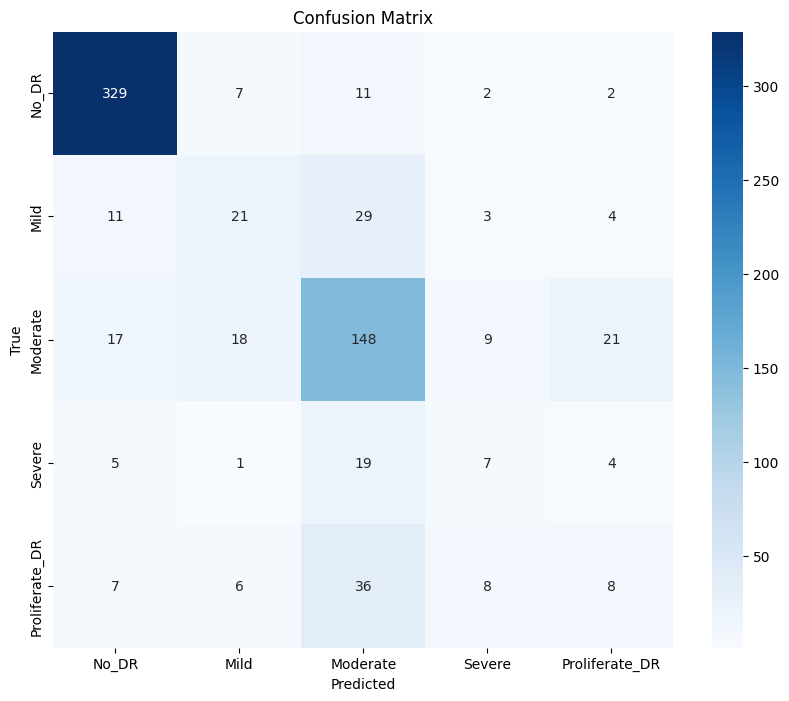

In [9]:
import numpy as np
import os
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from utils import load_data, preprocess_image

# Load the pre-trained VGG16 model
def load_vgg16_model(model_path):
    model = tf.keras.models.load_model(model_path)
    model.summary()
    return model

# Extract features from a chosen convolutional layer
def extract_features(model, img_array, layer_name='block5_conv3'):
    feature_extractor = tf.keras.Model(inputs=model.input, outputs=model.get_layer(layer_name).output)
    features = feature_extractor(img_array)
    return features.numpy().flatten()

# Train a Decision Tree classifier as a surrogate
def train_decision_tree(features, original_predictions, decision_tree):
    decision_tree.fit(features, original_predictions)
    return decision_tree

# Plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Main workflow to train Decision Tree and explain VGG16
def explain_vgg16_with_decision_tree(X_train, X_test, y_train, y_test, model_path, csv_file, base_image_dir, decision_tree):
    model = load_vgg16_model(model_path)
    
    # Prepare data
    # X_train, X_test, y_train, y_test = load_data(csv_file, base_image_dir)
    feature_list_train = []
    feature_list_test = []
    
    # Extract features for training data
    for img_path in X_train:
        img_array = preprocess_image(img_path)
        features = extract_features(model, img_array)
        feature_list_train.append(features)
    
    # Extract features for testing data
    for img_path in X_test:
        img_array = preprocess_image(img_path)
        features = extract_features(model, img_array)
        feature_list_test.append(features)
    
    # Train a Decision Tree using extracted features
    decision_tree = train_decision_tree(feature_list_train, y_train, decision_tree)
    
    # Make predictions on the test set
    y_pred = decision_tree.predict(feature_list_test)
    
    # Evaluate the model
    class_names = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']
    print(classification_report(y_test, y_pred, target_names=class_names))
    
    # Plot confusion matrix
    plot_confusion_matrix(y_test, y_pred, class_names)

# Usage
model_path = '../models/vgg16_model.keras'  # Path to your trained VGG16 model
csv_file = '../archive/train.csv'  # Path to your dataset CSV
base_image_dir = '../archive/gaussian_filtered_images'  # Path to your image directory
decision_tree = DecisionTreeClassifier(max_depth=10, random_state=42)
X_train, X_test, y_train, y_test = load_data(csv_file, base_image_dir)

explain_vgg16_with_decision_tree(X_train, X_test, y_train, y_test, model_path, csv_file, base_image_dir, decision_tree)


In [10]:
import joblib

# Save the trained Decision Tree model
model_save_path = '../models/vgg16_beta.pkl'
joblib.dump(decision_tree, model_save_path)

print(f"Decision Tree model saved at {model_save_path}")

Decision Tree model saved at ../models/vgg16_beta.pkl


In [11]:
import joblib
import numpy as np
from sklearn.metrics import accuracy_score

# Load the Decision Tree model
decision_tree_path = '../models/vgg16_beta.pkl'
decision_tree = joblib.load(decision_tree_path)

# Load the VGG16 model
vgg16_model_path = '../models/vgg16_model.keras'
vgg16_model = tf.keras.models.load_model(vgg16_model_path)

# Function to calculate fidelity
def calculate_fidelity(vgg16_model, decision_tree, X_test):
    vgg16_predictions = []
    decision_tree_predictions = []
    
    # Get predictions from both models
    for img_path in X_test:
        img_array = preprocess_image(img_path)
        
        # VGG16 predictions
        vgg16_pred = vgg16_model.predict(img_array)
        vgg16_predictions.append(np.argmax(vgg16_pred))
        
        # Decision Tree predictions
        features = extract_features(vgg16_model, img_array)
        decision_tree_pred = decision_tree.predict([features])[0]
        decision_tree_predictions.append(decision_tree_pred)
    
    # Calculate fidelity as accuracy of decision tree mimicking VGG16
    fidelity = accuracy_score(vgg16_predictions, decision_tree_predictions)
    return fidelity

# Function to calculate unambiguity (using depth of the tree)
def calculate_unambiguity(decision_tree):
    tree_depth = decision_tree.get_depth()
    return 1 / (tree_depth + 1)  # Higher depth = lower unambiguity

# Function to calculate interpretability (using number of nodes)
def calculate_interpretability(decision_tree):
    num_nodes = decision_tree.tree_.node_count
    return 1 / (num_nodes + 1)  # Fewer nodes = higher interpretability

# Example of calculating metrics
fidelity = calculate_fidelity(vgg16_model, decision_tree, X_test)  # X_test should be the test dataset paths
unambiguity = calculate_unambiguity(decision_tree)
interpretability = calculate_interpretability(decision_tree)

print(f"Fidelity: {fidelity}")
print(f"Unambiguity: {unambiguity}")
print(f"Interpretability: {interpretability}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━